In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
DATASET_DIR = "data/Dataset"
ROTATIONS = [0, 90, 180, 270]
LUMINANCE_FACTORS = [0.6, 0.8, 1.0, 1.2, 1.4]

class_dirs = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
class_to_idx = {cls: i for i, cls in enumerate(class_dirs)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Generate (path, rotation, luminance) tuples per class — no images loaded yet
samples_by_class = defaultdict(list)

for cls in class_dirs:
    cls_path = os.path.join(DATASET_DIR, cls)
    for fname in sorted(os.listdir(cls_path)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            fpath = os.path.join(cls_path, fname)
            for angle in ROTATIONS:
                for lum in LUMINANCE_FACTORS:
                    samples_by_class[cls].append((fpath, angle, lum))

print("Augmented sample counts per class:")
for cls in class_dirs:
    print(f"  {cls}: {len(samples_by_class[cls])}")

Augmented sample counts per class:
  Bishop (B): 2060
  Bishop (W): 2200
  Empty (B): 19600
  Empty (W): 18120
  King (B): 1100
  King (W): 1100
  Knight (B): 1600
  Knight (W): 1780
  Pawn (B): 8220
  Pawn (W): 8020
  Queen (B): 1100
  Queen (W): 1100
  Rook (B): 2200
  Rook (W): 2200


In [3]:
min_count = min(len(v) for v in samples_by_class.values())
print(f"Minimum class size after augmentation: {min_count}")
print(f"Truncating all classes to {min_count} samples...\n")

balanced_samples = []
balanced_labels = []

for cls in class_dirs:
    cls_samples = samples_by_class[cls].copy()
    random.shuffle(cls_samples)
    for sample in cls_samples[:min_count]:
        balanced_samples.append(sample)
        balanced_labels.append(cls)

print(f"Total samples: {len(balanced_samples)}")
print(f"Samples per class: {min_count}")
print(f"Number of classes: {len(class_dirs)}")

Minimum class size after augmentation: 1100
Truncating all classes to 1100 samples...

Total samples: 15400
Samples per class: 1100
Number of classes: 14


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class ChessDataset(Dataset):
    def __init__(self, samples, labels, class_to_idx, transform=None):
        self.samples = samples
        self.labels = [class_to_idx[l] for l in labels]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, rotation, lum_factor = self.samples[idx]
        img = Image.open(path).convert('RGB').resize((224, 224))
        if rotation != 0:
            img = img.rotate(rotation)
        img = ImageEnhance.Brightness(img).enhance(lum_factor)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Stratified 85/15 split
indices = list(range(len(balanced_samples)))
train_idx, test_idx = train_test_split(
    indices, test_size=0.15, stratify=balanced_labels, random_state=SEED
)

full_dataset = ChessDataset(balanced_samples, balanced_labels, class_to_idx, transform)
train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} samples | Test: {len(test_dataset)} samples")

Train: 13090 samples | Test: 2310 samples


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.last_channel, len(class_dirs))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Using device: cuda


In [6]:
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += out.argmax(1).eq(lbls).sum().item()
        total += lbls.size(0)

    scheduler.step()
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Loss: {running_loss/total:.4f}  "
          f"Acc: {correct/total:.4f}")

Epoch [ 1/15]  Loss: 0.1889  Acc: 0.9624
Epoch [ 2/15]  Loss: 0.0095  Acc: 0.9984
Epoch [ 3/15]  Loss: 0.0093  Acc: 0.9979
Epoch [ 4/15]  Loss: 0.0043  Acc: 0.9991
Epoch [ 5/15]  Loss: 0.0045  Acc: 0.9989
Epoch [ 6/15]  Loss: 0.0017  Acc: 0.9997
Epoch [ 7/15]  Loss: 0.0037  Acc: 0.9989
Epoch [ 8/15]  Loss: 0.0019  Acc: 0.9996
Epoch [ 9/15]  Loss: 0.0006  Acc: 0.9999
Epoch [10/15]  Loss: 0.0013  Acc: 0.9998
Epoch [11/15]  Loss: 0.0007  Acc: 0.9999
Epoch [12/15]  Loss: 0.0004  Acc: 1.0000
Epoch [13/15]  Loss: 0.0005  Acc: 0.9999
Epoch [14/15]  Loss: 0.0003  Acc: 1.0000
Epoch [15/15]  Loss: 0.0003  Acc: 1.0000


Test Accuracy: 1.0000


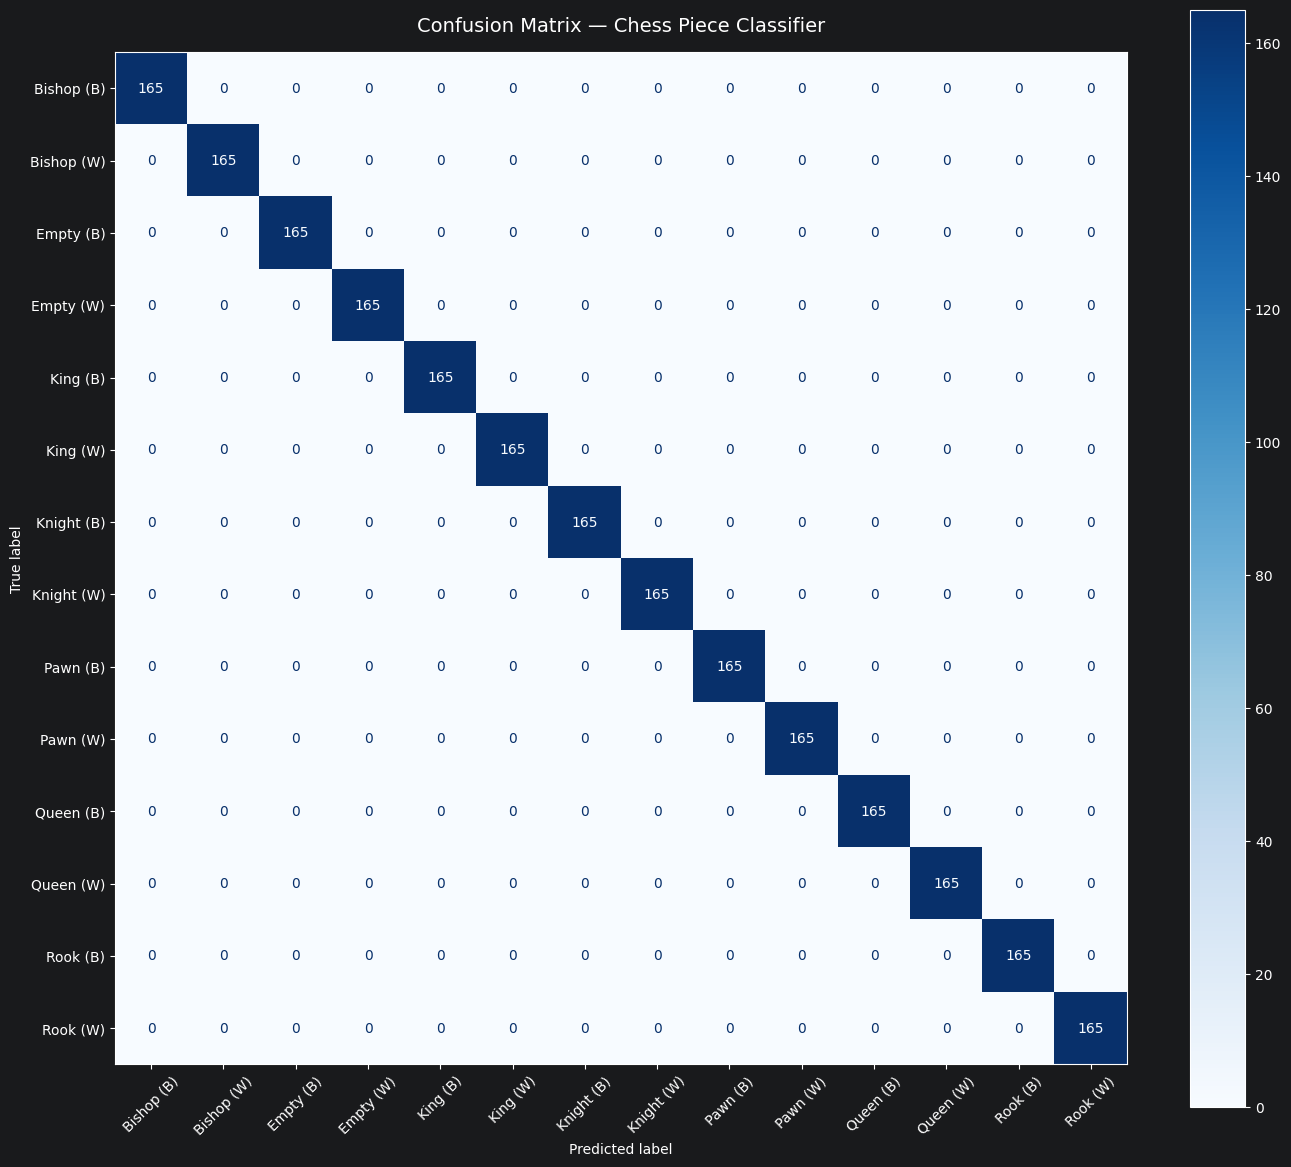

In [7]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(lbls.numpy())

test_acc = sum(p == t for p, t in zip(all_preds, all_true)) / len(all_true)
print(f"Test Accuracy: {test_acc:.4f}")

class_names = [idx_to_class[i] for i in range(len(class_dirs))]
cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Chess Piece Classifier", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
torch.save(model.state_dict(), "models/mobilenet.pth")

In [9]:
torch.save(model, "models/model.pth")